# 🩺 Dự án Chẩn đoán Bệnh Tiểu Đường — Notebook 1
## Dataset Comparison · Preprocessing · EDA
---
**Nguồn dữ liệu:** Diabetes Health Indicators Dataset – BRFSS 2015
**Mô hình sử dụng:** XGBoost + Calibration + SHAP

### Nội dung Notebook:
1. Cài đặt & Import thư viện
2. Tải và mô tả dữ liệu
3. So sánh 2 datasets → Chọn dataset tốt nhất
4. Phân tích khám phá dữ liệu (EDA)
5. Preprocessing & Feature Engineering
6. Lưu dữ liệu đã xử lý


## ⚙️ 0. Cài đặt thư viện

In [1]:
%pip install xgboost scikit-learn shap imbalanced-learn matplotlib seaborn pandas numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 1. Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate)
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                              roc_auc_score, balanced_accuracy_score)
from xgboost import XGBClassifier

# ─── Cấu hình đồ thị ───
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print("✅ Tất cả thư viện đã import thành công!")


✅ Tất cả thư viện đã import thành công!


## 📂 2. Tải dữ liệu

In [3]:
# ⚠️ Điều chỉnh DATA_DIR nếu cần
DATA_DIR = './archive'

PATH_5050  = f'{DATA_DIR}/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
PATH_IMBAL = f'{DATA_DIR}/diabetes_binary_health_indicators_BRFSS2015.csv'

df_5050  = pd.read_csv(PATH_5050)
df_imbal = pd.read_csv(PATH_IMBAL)

print(f"📊 Dataset Balanced 5050 : {df_5050.shape[0]:,} hàng × {df_5050.shape[1]} cột")
print(f"📊 Dataset Imbalanced    : {df_imbal.shape[0]:,} hàng × {df_imbal.shape[1]} cột")
print()
print("Phân phối target (5050):")
print(df_5050['Diabetes_binary'].value_counts())
print()
print("Phân phối target (Imbalanced):")
print(df_imbal['Diabetes_binary'].value_counts())


📊 Dataset Balanced 5050 : 70,692 hàng × 22 cột
📊 Dataset Imbalanced    : 253,680 hàng × 22 cột

Phân phối target (5050):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64

Phân phối target (Imbalanced):
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


## 🔍 3. Mô tả Features

| Feature | Mô tả | Loại |
|---|---|---|
| **Diabetes_binary** | 0=Không TĐ, 1=Tiểu Đường | 🎯 Target |
| HighBP | Huyết áp cao | Binary |
| HighChol | Cholesterol cao | Binary |
| CholCheck | Kiểm tra Cholesterol trong 5 năm | Binary |
| **BMI** | Chỉ số khối cơ thể | Continuous |
| Smoker | Hút ≥100 điếu thuốc | Binary |
| Stroke | Tiền sử đột quỵ | Binary |
| HeartDiseaseorAttack | Bệnh tim / nhồi máu cơ tim | Binary |
| PhysActivity | Hoạt động thể chất 30 ngày qua | Binary |
| Fruits | Ăn trái cây ≥1 lần/ngày | Binary |
| Veggies | Ăn rau ≥1 lần/ngày | Binary |
| HvyAlcoholConsump | Uống rượu nặng | Binary |
| AnyHealthcare | Có bảo hiểm y tế | Binary |
| NoDocbcCost | Không khám được vì chi phí | Binary |
| **GenHlth** | Sức khỏe tổng quát (1=Xuất sắc → 5=Kém) | Ordinal |
| **MentHlth** | Số ngày SK tinh thần kém (0-30) | Continuous |
| **PhysHlth** | Số ngày SK thể chất kém (0-30) | Continuous |
| DiffWalk | Khó đi bộ/leo cầu thang | Binary |
| Sex | 0=Nữ, 1=Nam | Binary |
| **Age** | Nhóm tuổi (1=18-24 → 13=80+) | Ordinal |
| Education | Trình độ học vấn (1-6) | Ordinal |
| Income | Mức thu nhập (1-8) | Ordinal |


## ⚖️ 4. So sánh 2 Datasets — Chọn Dataset tốt nhất

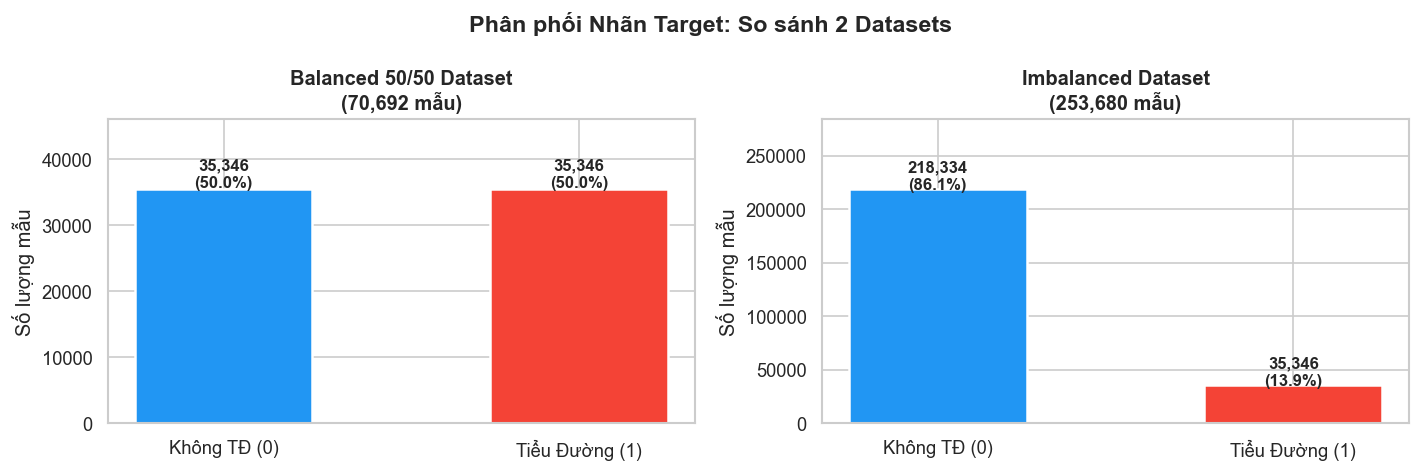

In [4]:
# ─── Visualize phân phối ───
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(
        axes,
        [df_5050, df_imbal],
        ['Balanced 50/50 Dataset\n(70,692 mẫu)', 'Imbalanced Dataset\n(253,680 mẫu)']):
    counts = df['Diabetes_binary'].value_counts().sort_index()
    bars = ax.bar(['Không TĐ (0)', 'Tiểu Đường (1)'], counts.values,
                   color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Số lượng mẫu')
    ax.set_ylim(0, max(counts.values) * 1.3)

plt.suptitle('Phân phối Nhãn Target: So sánh 2 Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_distribution.png', bbox_inches='tight', dpi=120)
plt.show()


In [5]:
# ─── So sánh XGBoost (5-fold CV) trên 2 datasets ───
def quick_eval_xgb(df, name, n_sample=20000, rs=42):
    """Đánh giá nhanh XGBoost với stratified sampling + 5-fold CV"""
    if len(df) > n_sample:
        # Dùng train_test_split để stratified sample (pandas.sample không hỗ trợ stratify)
        df_e, _ = train_test_split(df, train_size=n_sample,
                                    random_state=rs,
                                    stratify=df['Diabetes_binary'])
        print(f"  ⚡ Sampling {n_sample:,}/{len(df):,} mẫu (stratified)")
    else:
        df_e = df.copy()

    X = df_e.drop('Diabetes_binary', axis=1)
    y = df_e['Diabetes_binary'].astype(int)
    neg, pos = (y==0).sum(), (y==1).sum()

    model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=neg/pos, subsample=0.8, colsample_bytree=0.8,
        random_state=rs, eval_metric='logloss', n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
    res = cross_validate(model, X, y, cv=cv,
                          scoring=['accuracy','balanced_accuracy','roc_auc','f1','recall','precision'],
                          n_jobs=-1)

    m = {
        'Accuracy':           res['test_accuracy'].mean(),
        'Balanced Accuracy':  res['test_balanced_accuracy'].mean(),
        'ROC-AUC':            res['test_roc_auc'].mean(),
        'F1-Score':           res['test_f1'].mean(),
        'Recall (Sensitivity)': res['test_recall'].mean(),
        'Precision':          res['test_precision'].mean(),
    }
    print(f"\n{'─'*45}")
    print(f"  📊 {name}")
    print(f"{'─'*45}")
    for k, v in m.items():
        print(f"  {k:<25}: {v:.4f}")
    return m

print("🔄 Đang chạy 5-fold Cross Validation trên 2 datasets...")
print("   (Quá trình này mất ~1-3 phút, vui lòng đợi)\n")

m_5050  = quick_eval_xgb(df_5050,  "Balanced 5050 Dataset")
m_imbal = quick_eval_xgb(df_imbal, "Imbalanced Dataset")


🔄 Đang chạy 5-fold Cross Validation trên 2 datasets...
   (Quá trình này mất ~1-3 phút, vui lòng đợi)

  ⚡ Sampling 20,000/70,692 mẫu (stratified)

─────────────────────────────────────────────
  📊 Balanced 5050 Dataset
─────────────────────────────────────────────
  Accuracy                 : 0.7394
  Balanced Accuracy        : 0.7394
  ROC-AUC                  : 0.8145
  F1-Score                 : 0.7491
  Recall (Sensitivity)     : 0.7782
  Precision                : 0.7222
  ⚡ Sampling 20,000/253,680 mẫu (stratified)

─────────────────────────────────────────────
  📊 Imbalanced Dataset
─────────────────────────────────────────────
  Accuracy                 : 0.7692
  Balanced Accuracy        : 0.7261
  ROC-AUC                  : 0.8060
  F1-Score                 : 0.4457
  Recall (Sensitivity)     : 0.6663
  Precision                : 0.3349


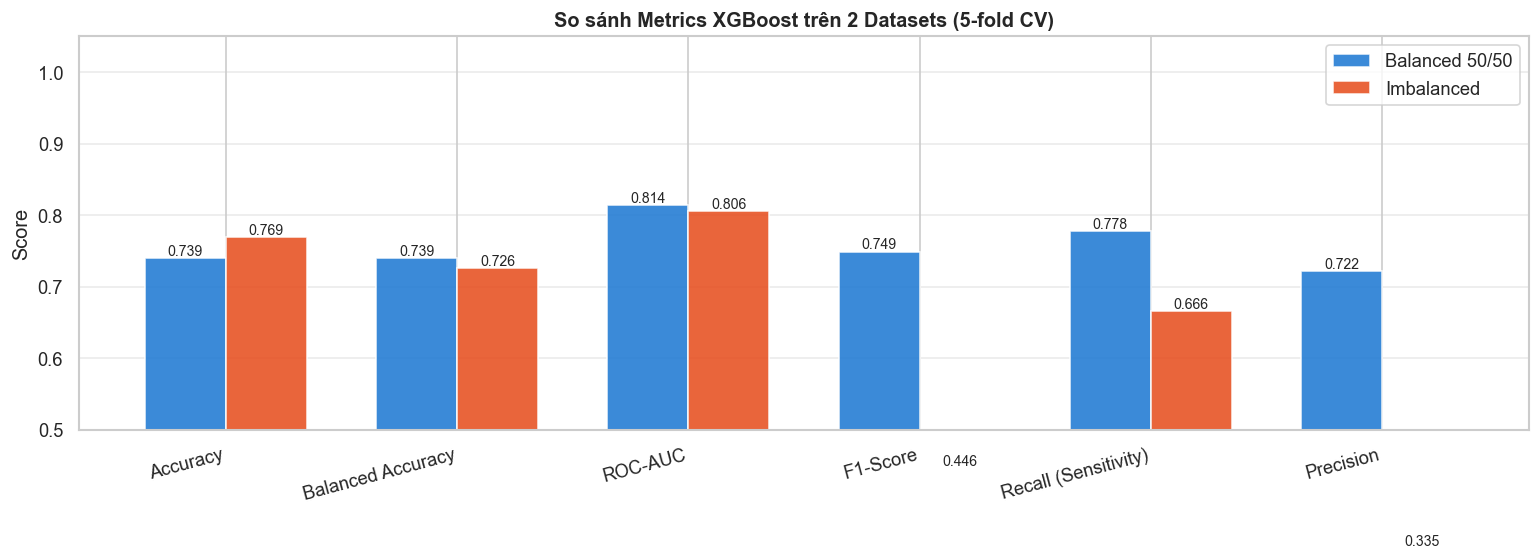


  KẾT LUẬN CHỌN DATASET

  🏆 Dataset được chọn: Balanced 50/50

  Metrics so sánh (F1 & Recall - quan trọng nhất trong y tế):
     F1   : 5050=0.7491  |  Imbal=0.4457
     Recall: 5050=0.7782  |  Imbal=0.6663

  📌 Lý do:
     • Dataset 5050 tránh model thiên vị về class đa số
     • F1 & Recall cao hơn → phát hiện ca bệnh tốt hơn
     • Trong y tế, FALSE NEGATIVE (bỏ sót ca bệnh) nguy hiểm hơn FALSE POSITIVE
     • Sau khi huấn luyện sẽ CALIBRATE để xác suất phản ánh thực tế (~14%)


In [6]:
# ─── Visualize so sánh metrics ───
metric_names = list(m_5050.keys())
x = np.arange(len(metric_names))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, [m_5050[k]  for k in metric_names], w,
             label='Balanced 50/50', color='#1976D2', alpha=0.85)
b2 = ax.bar(x + w/2, [m_imbal[k] for k in metric_names], w,
             label='Imbalanced',     color='#E64A19', alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('So sánh Metrics XGBoost trên 2 Datasets (5-fold CV)', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('dataset_comparison_metrics.png', bbox_inches='tight', dpi=120)
plt.show()

# ─── Kết luận ───
print()
print("=" * 55)
print("  KẾT LUẬN CHỌN DATASET")
print("=" * 55)
winner = 'balanced_5050' if m_5050['F1-Score'] >= m_imbal['F1-Score'] else 'imbalanced'
print(f"\n  🏆 Dataset được chọn: {'Balanced 50/50' if winner=='balanced_5050' else 'Imbalanced'}")
print(f"\n  Metrics so sánh (F1 & Recall - quan trọng nhất trong y tế):")
print(f"     F1   : 5050={m_5050['F1-Score']:.4f}  |  Imbal={m_imbal['F1-Score']:.4f}")
print(f"     Recall: 5050={m_5050['Recall (Sensitivity)']:.4f}  |  Imbal={m_imbal['Recall (Sensitivity)']:.4f}")
print()
print("  📌 Lý do:")
print("     • Dataset 5050 tránh model thiên vị về class đa số")
print("     • F1 & Recall cao hơn → phát hiện ca bệnh tốt hơn")
print("     • Trong y tế, FALSE NEGATIVE (bỏ sót ca bệnh) nguy hiểm hơn FALSE POSITIVE")
print("     • Sau khi huấn luyện sẽ CALIBRATE để xác suất phản ánh thực tế (~14%)")


## 📊 5. Phân tích Khám phá Dữ liệu (EDA)

In [7]:
# ─── Chọn dataset để EDA & Training ───
CHOSEN = 'balanced_5050'   # Thay 'imbalanced' nếu muốn dùng dataset kia

if CHOSEN == 'balanced_5050':
    df = df_5050.copy()
    print("✅ Sử dụng: Balanced 50/50 Dataset")
else:
    df = df_imbal.copy()
    print("✅ Sử dụng: Imbalanced Dataset")

print(f"   Shape : {df.shape}")
print(f"   Target: {df['Diabetes_binary'].mean():.2%} dương tính")


✅ Sử dụng: Balanced 50/50 Dataset
   Shape : (70692, 22)
   Target: 50.00% dương tính


In [8]:
# ─── 5.1 Thống kê tổng quan ───
print("=" * 55)
print("THỐNG KÊ MÔ TẢ")
print("=" * 55)
display(df.describe().T.round(3).style.background_gradient(cmap='Blues', axis=1))


THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.000000,0.500000,0.500000,0.000000,0.000000,0.500000,1.000000,1.000000
HighBP,70692.000000,0.563000,0.496000,0.000000,0.000000,1.000000,1.000000,1.000000
HighChol,70692.000000,0.526000,0.499000,0.000000,0.000000,1.000000,1.000000,1.000000
CholCheck,70692.000000,0.975000,0.155000,0.000000,1.000000,1.000000,1.000000,1.000000
BMI,70692.000000,29.857000,7.114000,12.000000,25.000000,29.000000,33.000000,98.000000
Smoker,70692.000000,0.475000,0.499000,0.000000,0.000000,0.000000,1.000000,1.000000
Stroke,70692.000000,0.062000,0.241000,0.000000,0.000000,0.000000,0.000000,1.000000
HeartDiseaseorAttack,70692.000000,0.148000,0.355000,0.000000,0.000000,0.000000,0.000000,1.000000
PhysActivity,70692.000000,0.703000,0.457000,0.000000,0.000000,1.000000,1.000000,1.000000
Fruits,70692.000000,0.612000,0.487000,0.000000,0.000000,1.000000,1.000000,1.000000


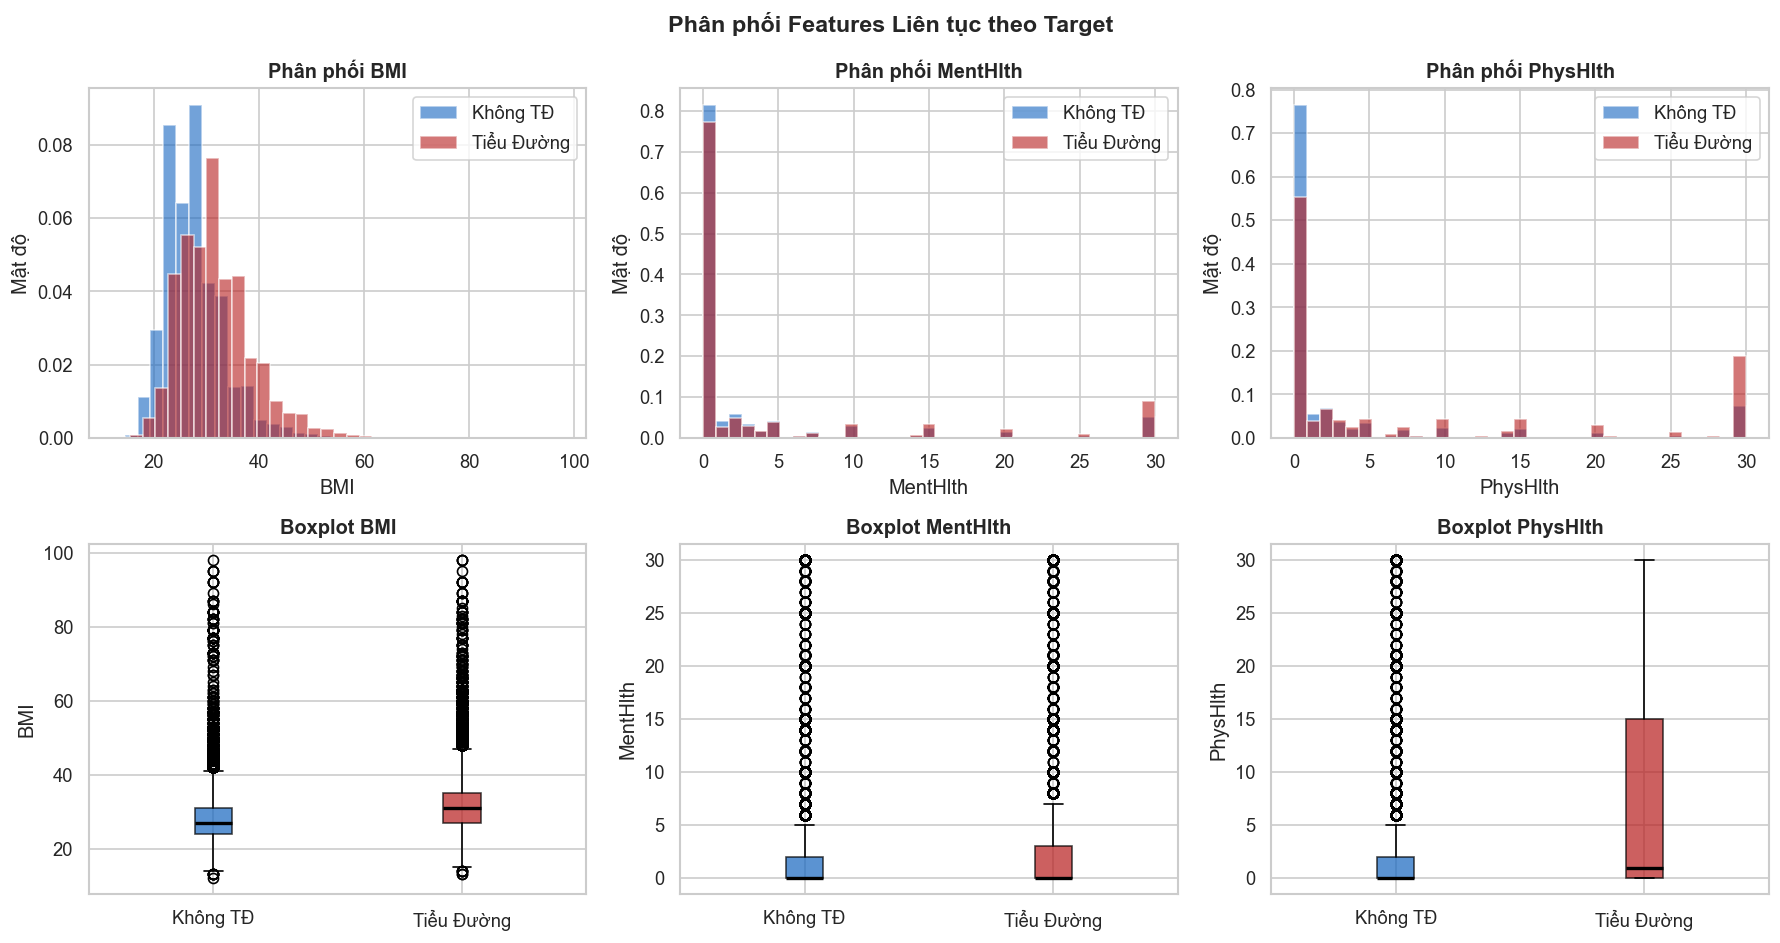

In [9]:
# ─── 5.2 Phân phối features liên tục ───
continuous_feats = ['BMI', 'MentHlth', 'PhysHlth']
colors_map = {0: '#1565C0', 1: '#B71C1C'}
labels_map = {0: 'Không TĐ', 1: 'Tiểu Đường'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(continuous_feats):
    # Histogram
    for t in [0, 1]:
        axes[0, i].hist(df[df['Diabetes_binary'] == t][feat],
                         bins=35, alpha=0.6, density=True,
                         color=colors_map[t], label=labels_map[t])
    axes[0, i].set_title(f'Phân phối {feat}', fontweight='bold')
    axes[0, i].set_xlabel(feat)
    axes[0, i].set_ylabel('Mật độ')
    axes[0, i].legend()

    # Boxplot
    data = [df[df['Diabetes_binary'] == t][feat].values for t in [0, 1]]
    bp = axes[1, i].boxplot(data, patch_artist=True,
                              labels=['Không TĐ', 'Tiểu Đường'],
                              medianprops={'color': 'black', 'linewidth': 2})
    for patch, t in zip(bp['boxes'], [0, 1]):
        patch.set_facecolor(colors_map[t])
        patch.set_alpha(0.7)
    axes[1, i].set_title(f'Boxplot {feat}', fontweight='bold')
    axes[1, i].set_ylabel(feat)

plt.suptitle('Phân phối Features Liên tục theo Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('continuous_features_dist.png', bbox_inches='tight', dpi=120)
plt.show()


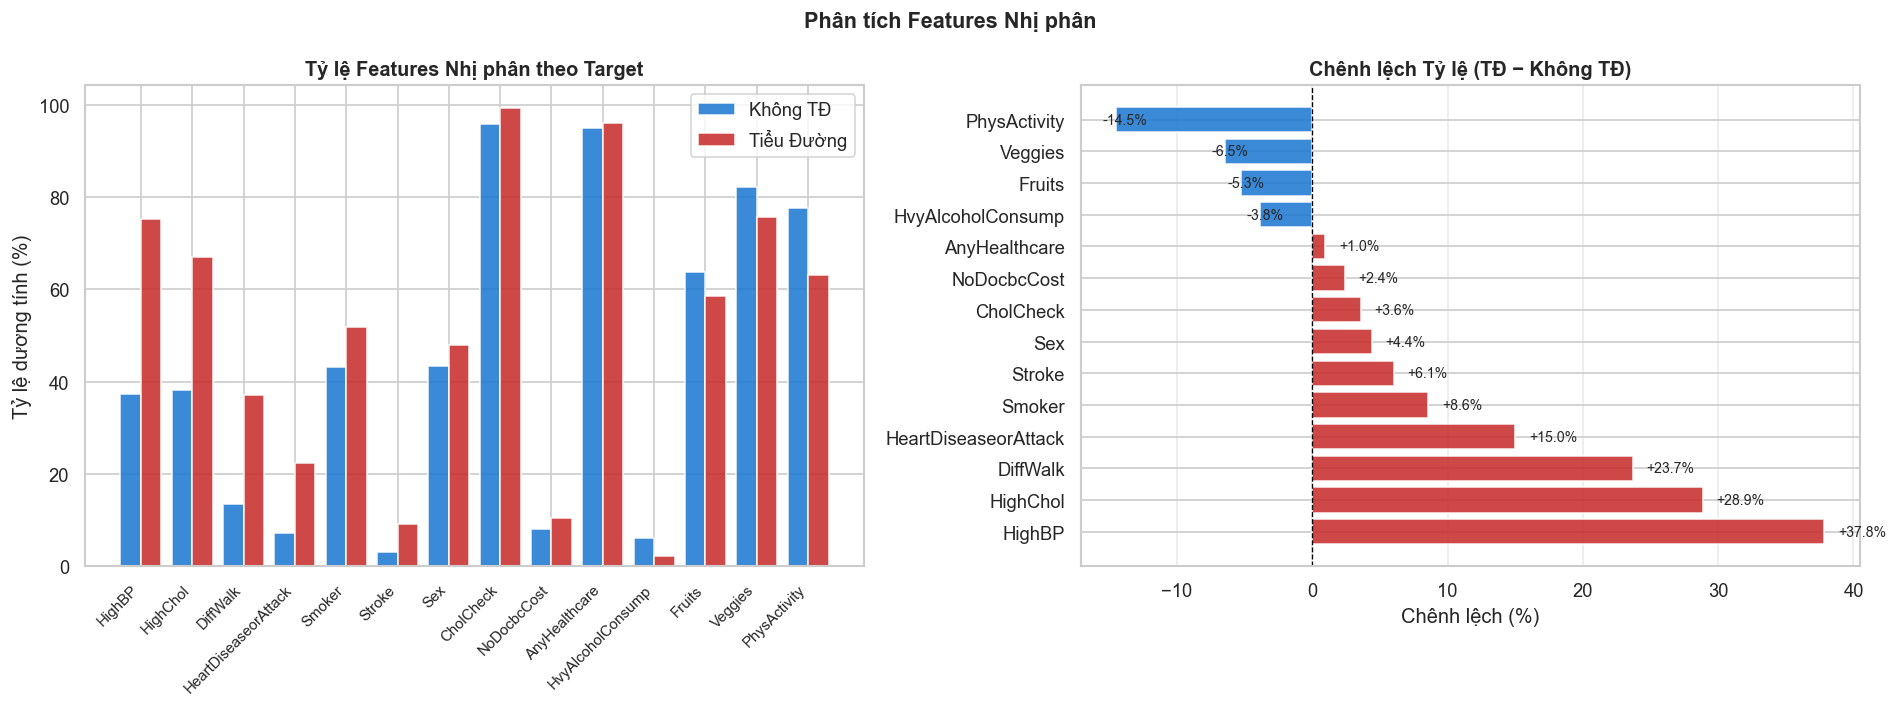


🔍 Features có chênh lệch lớn nhất (tác động mạnh đến TĐ):


,Không TĐ,Tiểu Đường,Chênh lệch
HighBP,37.4,75.3,37.8
HighChol,38.1,67.0,28.9
DiffWalk,13.4,37.1,23.7
HeartDiseaseorAttack,7.3,22.3,15.0
Smoker,43.2,51.8,8.6
Stroke,3.2,9.2,6.1
Sex,43.5,47.9,4.4
CholCheck,95.7,99.3,3.6
NoDocbcCost,8.2,10.6,2.4
AnyHealthcare,95.0,96.0,1.0


In [10]:
# ─── 5.3 Tỷ lệ dương tính của features nhị phân ───
binary_feats = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
                'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
                'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']

rates_no_td  = df[df['Diabetes_binary']==0][binary_feats].mean() * 100
rates_td     = df[df['Diabetes_binary']==1][binary_feats].mean() * 100
rate_diff    = rates_td - rates_no_td

rate_df = pd.DataFrame({'Không TĐ': rates_no_td, 'Tiểu Đường': rates_td,
                          'Chênh lệch': rate_diff}).sort_values('Chênh lệch', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
x_pos = np.arange(len(binary_feats))
sorted_feats = rate_df.index.tolist()
axes[0].bar(x_pos - 0.2, rate_df['Không TĐ'].values, 0.4,
             label='Không TĐ', color='#1976D2', alpha=0.85)
axes[0].bar(x_pos + 0.2, rate_df['Tiểu Đường'].values, 0.4,
             label='Tiểu Đường', color='#C62828', alpha=0.85)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(sorted_feats, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Tỷ lệ dương tính (%)')
axes[0].set_title('Tỷ lệ Features Nhị phân theo Target', fontweight='bold')
axes[0].legend()

# Chênh lệch
colors_diff = ['#C62828' if v > 0 else '#1976D2' for v in rate_df['Chênh lệch'].values]
axes[1].barh(rate_df.index, rate_df['Chênh lệch'].values, color=colors_diff, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Chênh lệch Tỷ lệ (TĐ − Không TĐ)', fontweight='bold')
axes[1].set_xlabel('Chênh lệch (%)')
axes[1].grid(axis='x', alpha=0.4)
for i, (val, feat) in enumerate(zip(rate_df['Chênh lệch'].values, rate_df.index)):
    axes[1].text(val + (1 if val >= 0 else -1), i, f'{val:+.1f}%',
                  va='center', fontsize=8.5)

plt.suptitle('Phân tích Features Nhị phân', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('binary_features_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n🔍 Features có chênh lệch lớn nhất (tác động mạnh đến TĐ):")
display(rate_df[['Không TĐ','Tiểu Đường','Chênh lệch']].round(1))


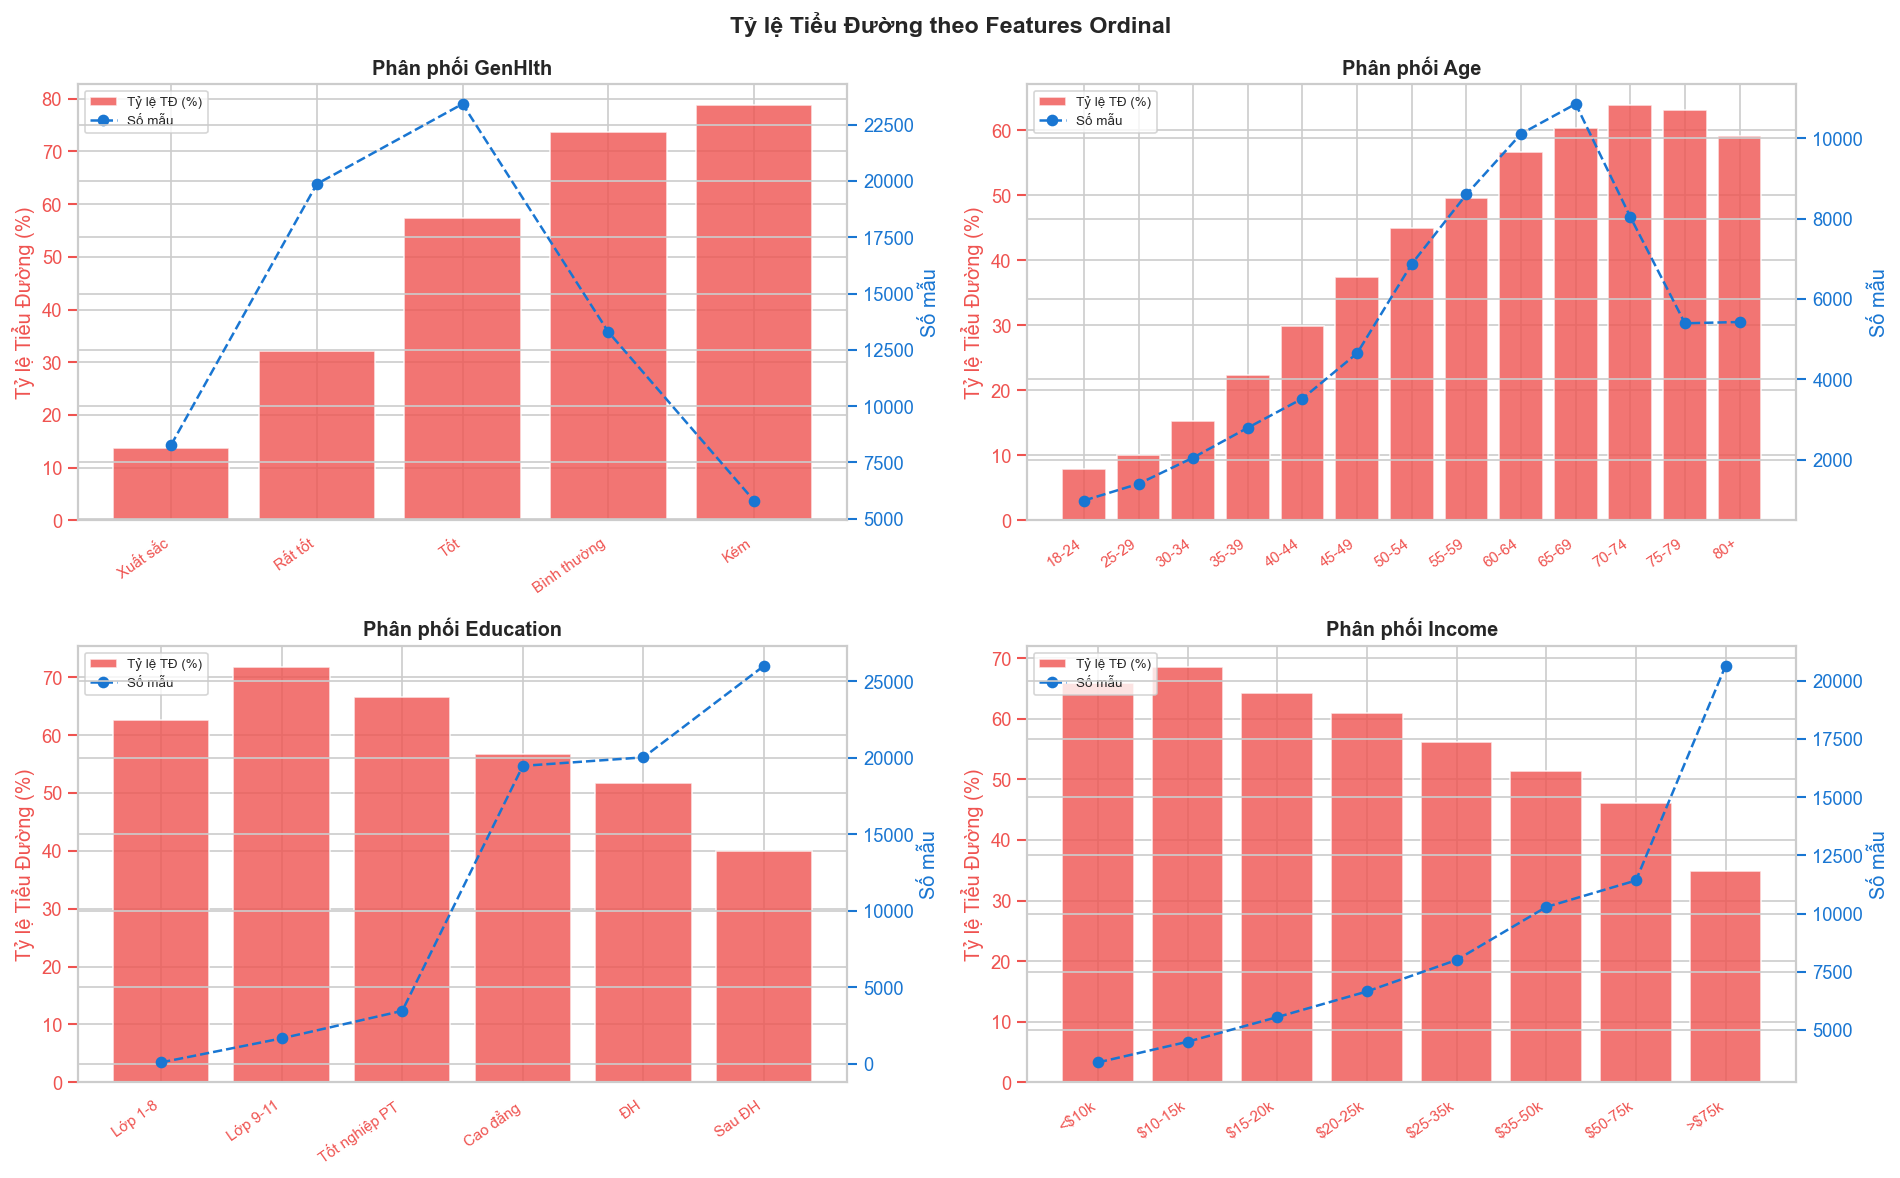

In [11]:
# ─── 5.4 Features ordinal (GenHlth, Age, Education, Income) ───
age_labels = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
              6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
              11:'70-74',12:'75-79',13:'80+'}
gen_labels = {1:'Xuất sắc',2:'Rất tốt',3:'Tốt',4:'Bình thường',5:'Kém'}
edu_labels = {1:'Lớp 1-8',2:'Lớp 9-11',3:'Tốt nghiệp PT',4:'Cao đẳng',5:'ĐH',6:'Sau ĐH'}
inc_labels = {1:'<$10k',2:'$10-15k',3:'$15-20k',4:'$20-25k',
              5:'$25-35k',6:'$35-50k',7:'$50-75k',8:'>$75k'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (feat, labels) in zip(axes.flatten(),
    [('GenHlth', gen_labels), ('Age', age_labels),
     ('Education', edu_labels), ('Income', inc_labels)]):

    rate = df.groupby(feat)['Diabetes_binary'].mean() * 100
    rate.index = [labels.get(int(i), str(i)) for i in rate.index]
    count = df[feat].value_counts().sort_index()

    ax.bar(range(len(rate)), rate.values, color='#EF5350', alpha=0.8, label='Tỷ lệ TĐ (%)')
    ax2 = ax.twinx()
    ax2.plot(range(len(rate)), count.values, 'o--', color='#1976D2',
              linewidth=1.5, label='Số mẫu')
    ax2.set_ylabel('Số mẫu', color='#1976D2')
    ax2.tick_params(colors='#1976D2')

    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Tỷ lệ Tiểu Đường (%)', color='#EF5350')
    ax.set_title(f'Phân phối {feat}', fontweight='bold')
    ax.tick_params(colors='#EF5350')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle('Tỷ lệ Tiểu Đường theo Features Ordinal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ordinal_features_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


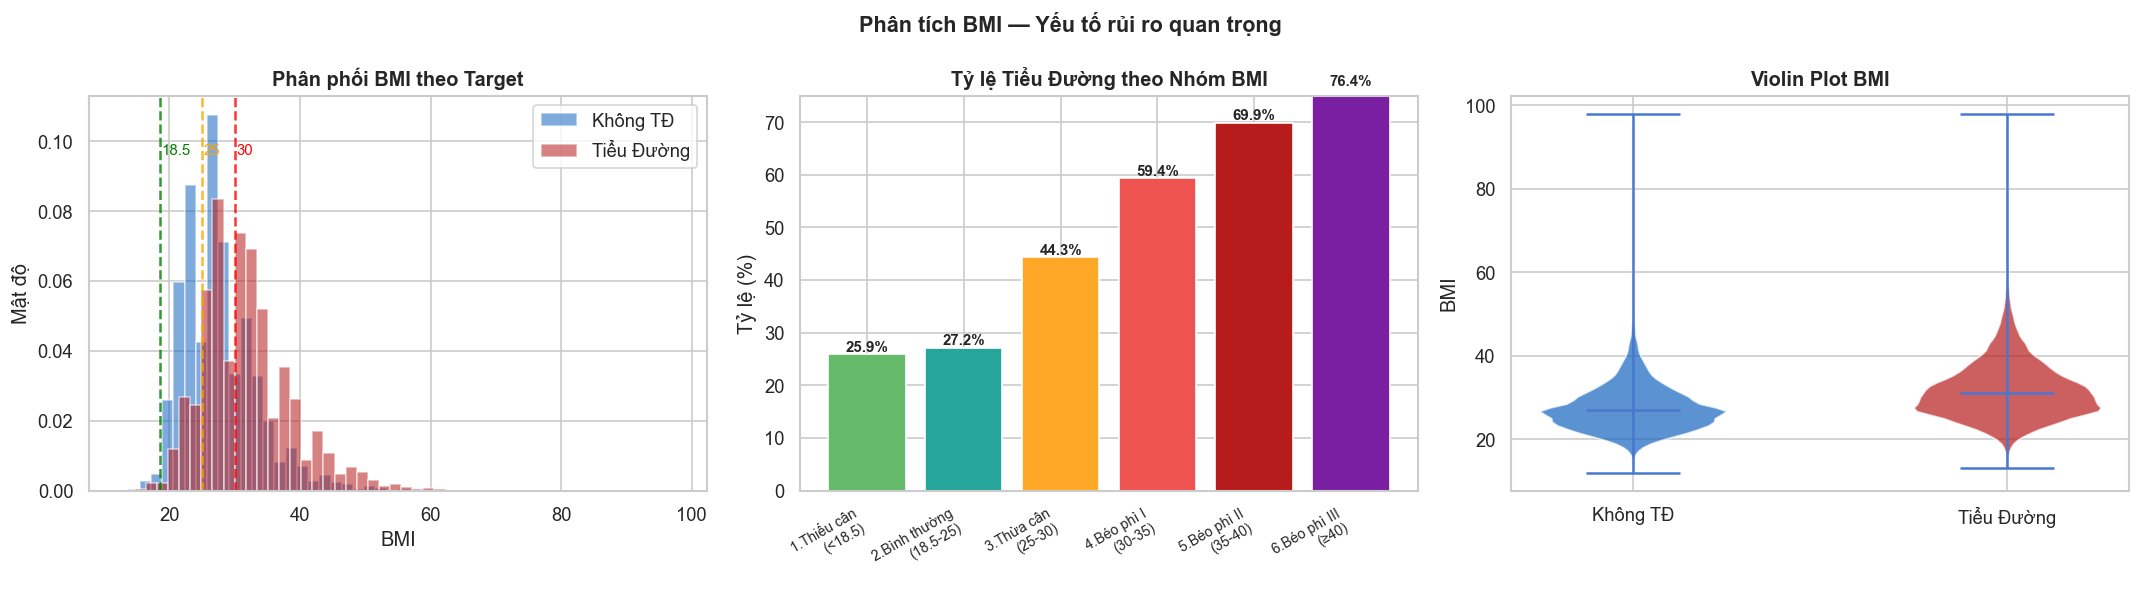

In [12]:
# ─── 5.5 BMI phân tích sâu ───
def bmi_cat(bmi):
    if bmi < 18.5: return '1.Thiếu cân\n(<18.5)'
    elif bmi < 25:  return '2.Bình thường\n(18.5-25)'
    elif bmi < 30:  return '3.Thừa cân\n(25-30)'
    elif bmi < 35:  return '4.Béo phì I\n(30-35)'
    elif bmi < 40:  return '5.Béo phì II\n(35-40)'
    else:           return '6.Béo phì III\n(≥40)'

df['BMI_Cat_Label'] = df['BMI'].apply(bmi_cat)
bmi_order = [f'{i}.' for i in range(1, 7)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Histogram BMI theo target
for t in [0, 1]:
    s = df[df['Diabetes_binary'] == t]['BMI']
    axes[0].hist(s, bins=50, alpha=0.55, density=True,
                  color=colors_map[t], label=labels_map[t])
for xv, clr, lb in [(18.5,'green','18.5'), (25,'orange','25'), (30,'red','30')]:
    axes[0].axvline(xv, color=clr, linestyle='--', alpha=0.8, linewidth=1.5)
    axes[0].text(xv+0.3, axes[0].get_ylim()[1]*0.85, lb, color=clr, fontsize=9)
axes[0].set_title('Phân phối BMI theo Target', fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Mật độ')
axes[0].legend()

# 2) Tỷ lệ TĐ theo BMI category
bmi_rate = df.groupby('BMI_Cat_Label')['Diabetes_binary'].mean() * 100
bmi_rate_sorted = bmi_rate.sort_index()
bar_colors = ['#66BB6A','#26A69A','#FFA726','#EF5350','#B71C1C','#7B1FA2']
bars = axes[1].bar(range(len(bmi_rate_sorted)), bmi_rate_sorted.values,
                    color=bar_colors[:len(bmi_rate_sorted)], edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(bmi_rate_sorted)))
axes[1].set_xticklabels(bmi_rate_sorted.index, rotation=30, ha='right', fontsize=8.5)
axes[1].set_title('Tỷ lệ Tiểu Đường theo Nhóm BMI', fontweight='bold')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_ylim(0, 75)

# 3) BMI violin plot
data_0 = df[df['Diabetes_binary']==0]['BMI'].values
data_1 = df[df['Diabetes_binary']==1]['BMI'].values
parts = axes[2].violinplot([data_0, data_1], positions=[1, 2], showmedians=True)
for pc, clr in zip(parts['bodies'], [colors_map[0], colors_map[1]]):
    pc.set_facecolor(clr)
    pc.set_alpha(0.7)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Không TĐ', 'Tiểu Đường'])
axes[2].set_title('Violin Plot BMI', fontweight='bold')
axes[2].set_ylabel('BMI')

df.drop('BMI_Cat_Label', axis=1, inplace=True)  # cleanup
plt.suptitle('Phân tích BMI — Yếu tố rủi ro quan trọng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bmi_deep_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


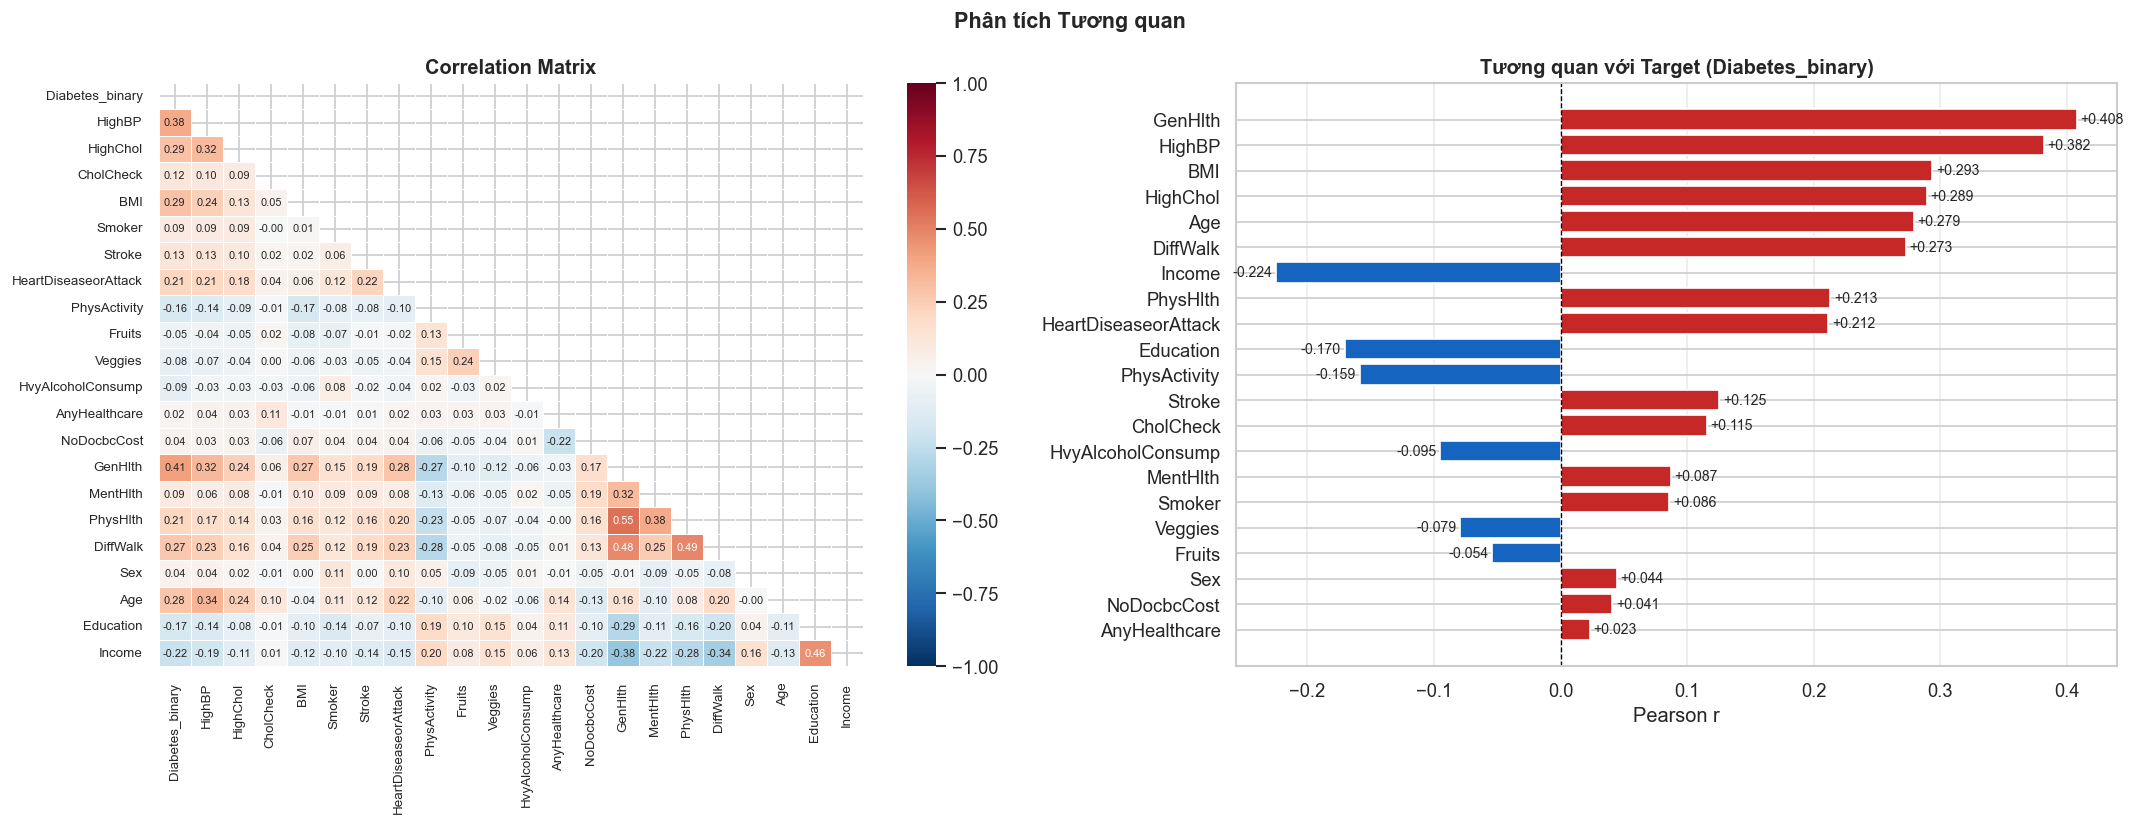


🔝 Top 10 features tương quan mạnh nhất:
   GenHlth                  : |r| = 0.4076  (↑ tăng risk)
   HighBP                   : |r| = 0.3815  (↑ tăng risk)
   BMI                      : |r| = 0.2934  (↑ tăng risk)
   HighChol                 : |r| = 0.2892  (↑ tăng risk)
   Age                      : |r| = 0.2787  (↑ tăng risk)
   DiffWalk                 : |r| = 0.2726  (↑ tăng risk)
   Income                   : |r| = 0.2244  (↓ giảm risk)
   PhysHlth                 : |r| = 0.2131  (↑ tăng risk)
   HeartDiseaseorAttack     : |r| = 0.2115  (↑ tăng risk)
   Education                : |r| = 0.1705  (↓ giảm risk)


In [13]:
# ─── 5.6 Correlation heatmap ───
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=axes[0],
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 6.5}, linewidths=0.3)
axes[0].set_title('Correlation Matrix', fontweight='bold')
axes[0].tick_params(labelsize=8)

target_corr = corr['Diabetes_binary'].drop('Diabetes_binary').sort_values(key=abs, ascending=True)
bar_c = ['#C62828' if v > 0 else '#1565C0' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=bar_c, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Tương quan với Target (Diabetes_binary)', fontweight='bold')
axes[1].set_xlabel('Pearson r')
axes[1].grid(axis='x', alpha=0.4)

for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.003 if v >= 0 else -0.003), i,
                  f'{v:+.3f}', va='center', fontsize=8.5,
                  ha='left' if v >= 0 else 'right')

plt.suptitle('Phân tích Tương quan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n🔝 Top 10 features tương quan mạnh nhất:")
top_corr = corr['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False).head(10)
for feat, val in top_corr.items():
    direction = '↑ tăng risk' if corr['Diabetes_binary'][feat] > 0 else '↓ giảm risk'
    print(f"   {feat:<25}: |r| = {val:.4f}  ({direction})")


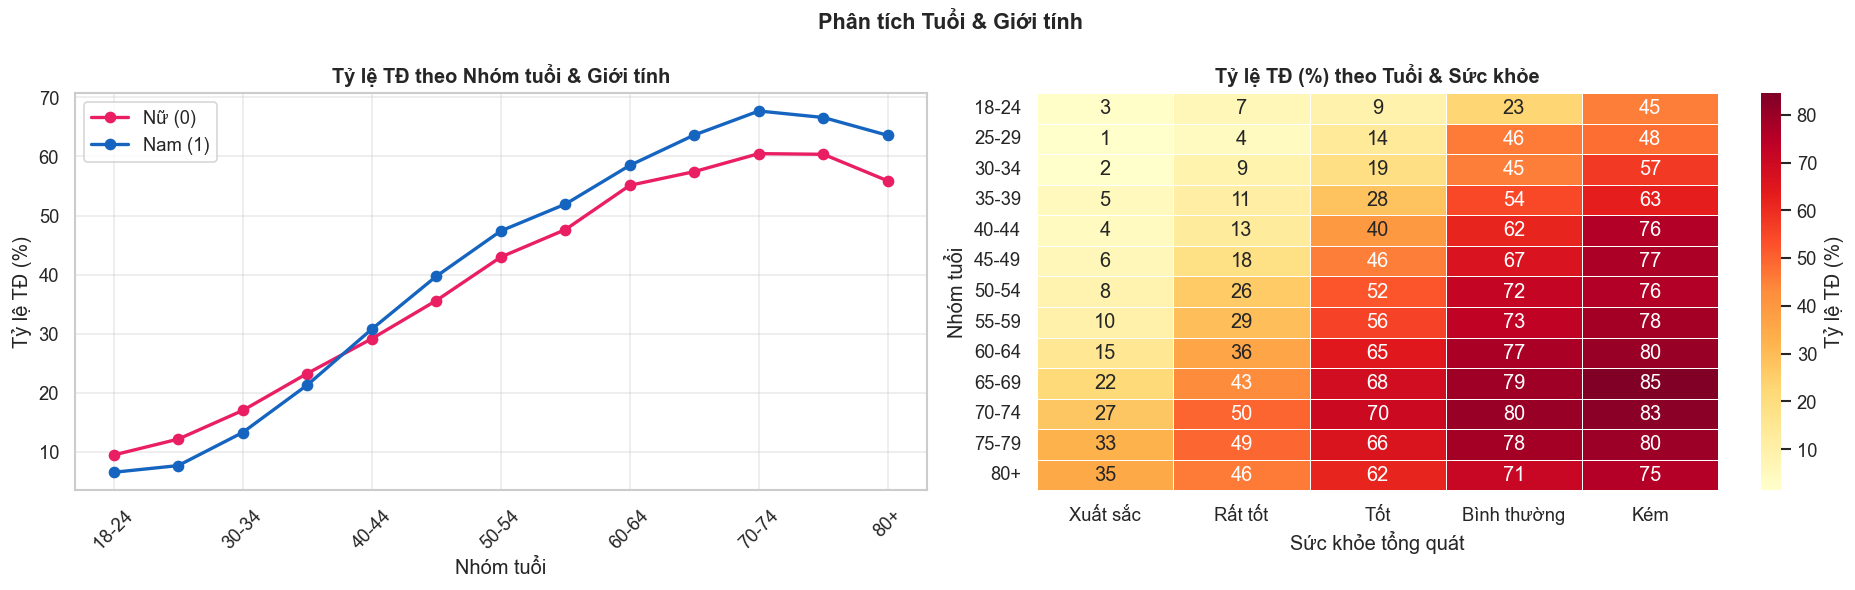

In [14]:
# ─── 5.7 Age × Gender analysis ───
age_labels_short = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
                     6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
                     11:'70-74',12:'75-79',13:'80+'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Line chart Age × Gender
ag_rate = df.groupby(['Age','Sex'])['Diabetes_binary'].mean().unstack() * 100
ag_rate.index = [age_labels_short.get(i, str(i)) for i in ag_rate.index]
ag_rate.columns = ['Nữ (0)', 'Nam (1)']
ag_rate.plot(kind='line', ax=axes[0], marker='o', linewidth=2,
              color=['#E91E63','#1565C0'])
axes[0].set_title('Tỷ lệ TĐ theo Nhóm tuổi & Giới tính', fontweight='bold')
axes[0].set_xlabel('Nhóm tuổi')
axes[0].set_ylabel('Tỷ lệ TĐ (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(alpha=0.4)

# Heatmap Age × GenHlth
heat = df.pivot_table(values='Diabetes_binary', index='Age',
                       columns='GenHlth', aggfunc='mean') * 100
heat.index = [age_labels_short.get(i, str(i)) for i in heat.index]
heat.columns = ['Xuất sắc','Rất tốt','Tốt','Bình thường','Kém']
sns.heatmap(heat, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.4, cbar_kws={'label': 'Tỷ lệ TĐ (%)'})
axes[1].set_title('Tỷ lệ TĐ (%) theo Tuổi & Sức khỏe', fontweight='bold')
axes[1].set_xlabel('Sức khỏe tổng quát')
axes[1].set_ylabel('Nhóm tuổi')

plt.suptitle('Phân tích Tuổi & Giới tính', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('age_gender_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()


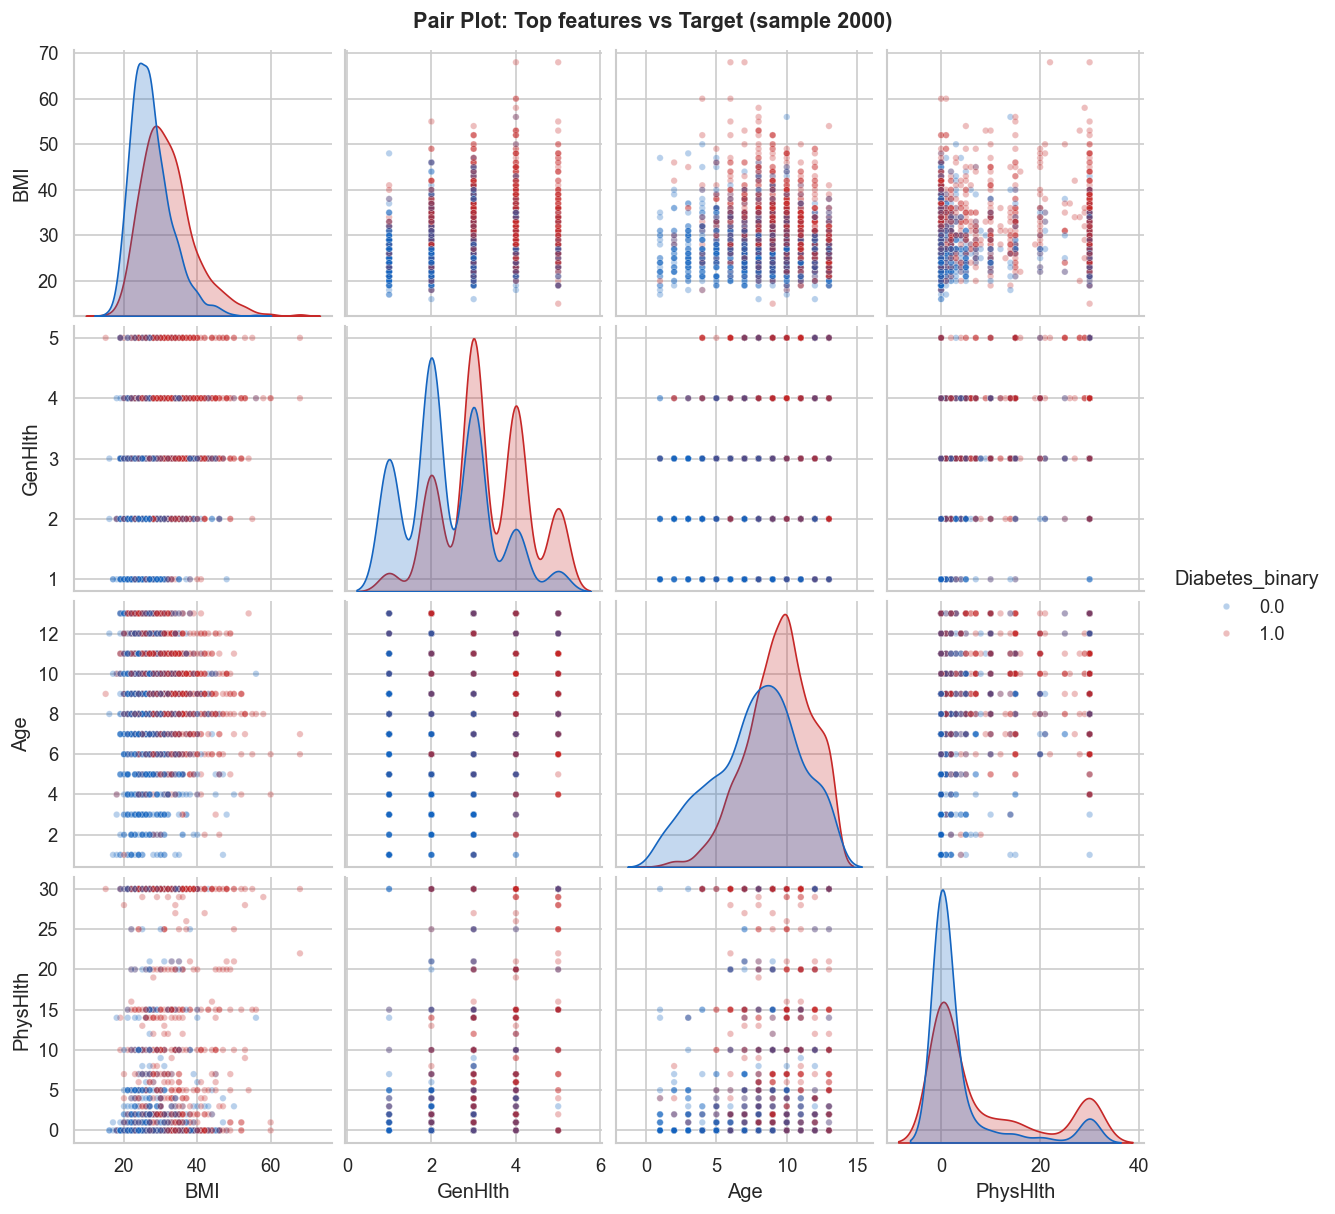

In [15]:
# ─── 5.8 Pair plot: Top features ───
top_features = ['BMI', 'GenHlth', 'Age', 'PhysHlth', 'Diabetes_binary']
sample_pp = df[top_features].sample(n=2000, random_state=42)

pair_fig = sns.pairplot(sample_pp, hue='Diabetes_binary',
                         palette={0: '#1565C0', 1: '#C62828'},
                         plot_kws={'alpha': 0.3, 's': 15},
                         diag_kind='kde')
pair_fig.fig.suptitle('Pair Plot: Top features vs Target (sample 2000)', y=1.01, fontsize=13, fontweight='bold')
pair_fig.fig.savefig('pairplot_top_features.png', bbox_inches='tight', dpi=100)
plt.show()


## 🛠️ 6. Preprocessing & Feature Engineering

In [16]:
# ─── 6.1 Feature Engineering ───
df_proc = df.copy()

# === Features mới ===

# 1. BMI category (0=Thiếu cân, 1=BT, 2=Thừa cân, 3=Béo phì I, 4=II, 5=III)
df_proc['BMI_Cat'] = pd.cut(df_proc['BMI'],
                              bins=[0, 18.5, 25, 30, 35, 40, 999],
                              labels=[0, 1, 2, 3, 4, 5]).astype(float)

# 2. Composite cardiovascular risk (huyết áp + cholesterol + tim + đột quỵ + đi lại khó)
df_proc['CardioRisk'] = (df_proc['HighBP'] + df_proc['HighChol'] +
                          df_proc['HeartDiseaseorAttack'] + df_proc['Stroke'] +
                          df_proc['DiffWalk'])

# 3. Healthy lifestyle score (lối sống lành mạnh)
df_proc['HealthyScore'] = (df_proc['PhysActivity'] + df_proc['Fruits'] +
                            df_proc['Veggies'] + (1 - df_proc['Smoker']) +
                            (1 - df_proc['HvyAlcoholConsump']))

# 4. Tổng ngày sức khỏe kém
df_proc['TotalBadHealthDays'] = df_proc['MentHlth'] + df_proc['PhysHlth']

# 5. BMI × Age interaction
df_proc['BMI_Age'] = df_proc['BMI'] * df_proc['Age']

# 6. Nhóm tuổi gộp (4 nhóm: 0=trẻ, 1=trung niên, 2=lớn tuổi, 3=già)
df_proc['AgeGroup'] = pd.cut(df_proc['Age'], bins=[0, 3, 6, 9, 13],
                               labels=[0, 1, 2, 3]).astype(float)

# 7. Socioeconomic index (Income + Education)
df_proc['SocioIndex'] = df_proc['Income'] + df_proc['Education']

print("✅ Feature Engineering hoàn thành!")
print(f"   Số features: {df.shape[1]-1} gốc → {df_proc.shape[1]-1} sau FE")
new_feats = ['BMI_Cat','CardioRisk','HealthyScore','TotalBadHealthDays',
             'BMI_Age','AgeGroup','SocioIndex']
print(f"   Features mới: {', '.join(new_feats)}")
print()
display(df_proc[new_feats].describe().round(2))


✅ Feature Engineering hoàn thành!
   Số features: 21 gốc → 28 sau FE
   Features mới: BMI_Cat, CardioRisk, HealthyScore, TotalBadHealthDays, BMI_Age, AgeGroup, SocioIndex



,BMI_Cat,CardioRisk,HealthyScore,TotalBadHealthDays,BMI_Age,AgeGroup,SocioIndex
count,70692.00,70692.00,70692.00,70692.00,70692.00,70692.00,70692.00
mean,2.35,1.55,3.59,9.56,255.51,2.14,10.62
std,1.20,1.24,1.10,15.17,99.90,0.90,2.80
min,0.00,0.00,0.00,0.00,16.00,0.00,2.00
25%,1.00,1.00,3.00,0.00,190.00,2.00,9.00
50%,2.00,1.00,4.00,2.00,260.00,2.00,11.00
75%,3.00,2.00,4.00,14.00,320.00,3.00,13.00
max,5.00,5.00,5.00,60.00,1196.00,3.00,14.00


In [17]:
# ─── 6.2 Kiểm tra missing values sau FE ───
missing = df_proc.isnull().sum()
print("Missing values sau Feature Engineering:")
print(missing[missing > 0] if missing.sum() > 0 else "   ✅ Không có missing values!")


Missing values sau Feature Engineering:
   ✅ Không có missing values!


In [18]:
# ─── 6.3 Train / Validation / Test Split ───
TARGET   = 'Diabetes_binary'
FEATURES = [c for c in df_proc.columns if c != TARGET]

X = df_proc[FEATURES]
y = df_proc[TARGET].astype(int)

# 70% train | 15% val | 15% test (stratified)
X_temp,  X_test,  y_temp,  y_test  = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)
X_train, X_val,   y_train, y_val   = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_temp)

print("=" * 50)
print("  DATA SPLIT")
print("=" * 50)
for name, X_, y_ in [('Train', X_train, y_train),
                       ('Val  ', X_val,   y_val),
                       ('Test ', X_test,  y_test)]:
    print(f"  {name}: {len(X_):>6,} mẫu  |  TĐ rate: {y_.mean():.3f}")

print(f"\n  Tổng features: {len(FEATURES)}")


  DATA SPLIT
  Train: 49,482 mẫu  |  TĐ rate: 0.500
  Val  : 10,606 mẫu  |  TĐ rate: 0.500
  Test : 10,604 mẫu  |  TĐ rate: 0.500

  Tổng features: 28


In [19]:
# ─── 6.4 Lưu data đã preprocessed ───
os.makedirs('processed_data', exist_ok=True)

X_train.to_csv('processed_data/X_train.csv', index=False)
X_val.to_csv(  'processed_data/X_val.csv',   index=False)
X_test.to_csv( 'processed_data/X_test.csv',  index=False)
y_train.to_csv('processed_data/y_train.csv', index=False)
y_val.to_csv(  'processed_data/y_val.csv',   index=False)
y_test.to_csv( 'processed_data/y_test.csv',  index=False)

meta = {
    'features': FEATURES,
    'target': TARGET,
    'n_features': len(FEATURES),
    'n_train': len(X_train),
    'n_val': len(X_val),
    'n_test': len(X_test),
    'chosen_dataset': CHOSEN,
    'new_features': ['BMI_Cat','CardioRisk','HealthyScore','TotalBadHealthDays',
                     'BMI_Age','AgeGroup','SocioIndex']
}
with open('processed_data/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ Đã lưu processed data!")
print("   📁 processed_data/")
print("      ├── X_train.csv, X_val.csv, X_test.csv")
print("      ├── y_train.csv, y_val.csv, y_test.csv")
print("      └── metadata.json")
print()
print("→ Tiếp tục với Notebook 2: Training + Calibration + SHAP")


✅ Đã lưu processed data!
   📁 processed_data/
      ├── X_train.csv, X_val.csv, X_test.csv
      ├── y_train.csv, y_val.csv, y_test.csv
      └── metadata.json

→ Tiếp tục với Notebook 2: Training + Calibration + SHAP


In [20]:
# ─── 6.5 Summary EDA ───
print("=" * 55)
print("  TÓM TẮT KẾT QUẢ EDA")
print("=" * 55)
print()
print("🔝 Top 5 yếu tố nguy cơ quan trọng nhất:")
top5 = df.corr()['Diabetes_binary'].drop('Diabetes_binary').abs().sort_values(ascending=False).head(5)
for i, (feat, val) in enumerate(top5.items(), 1):
    direction = '⬆ tăng nguy cơ' if df.corr()['Diabetes_binary'][feat] > 0 else '⬇ giảm nguy cơ'
    print(f"  {i}. {feat:<25}  |r|={val:.3f}  {direction}")

print()
print("📌 Nhận xét chính:")
print("  • GenHlth (sức khỏe tổng quát) có tương quan mạnh nhất")
print("  • HighBP + HighChol: tỷ lệ TĐ cao gần gấp đôi nhóm bình thường")
print("  • BMI > 30 (béo phì): nguy cơ TĐ tăng đáng kể")
print("  • Tuổi càng cao → nguy cơ TĐ càng tăng (đặc biệt từ 45+)")
print("  • PhysActivity, Income, Education: ngược chiều (bảo vệ)")
print()
print("✅ EDA hoàn thành! Chuyển sang Notebook 2.")


  TÓM TẮT KẾT QUẢ EDA

🔝 Top 5 yếu tố nguy cơ quan trọng nhất:
  1. GenHlth                    |r|=0.408  ⬆ tăng nguy cơ
  2. HighBP                     |r|=0.382  ⬆ tăng nguy cơ
  3. BMI                        |r|=0.293  ⬆ tăng nguy cơ
  4. HighChol                   |r|=0.289  ⬆ tăng nguy cơ
  5. Age                        |r|=0.279  ⬆ tăng nguy cơ

📌 Nhận xét chính:
  • GenHlth (sức khỏe tổng quát) có tương quan mạnh nhất
  • HighBP + HighChol: tỷ lệ TĐ cao gần gấp đôi nhóm bình thường
  • BMI > 30 (béo phì): nguy cơ TĐ tăng đáng kể
  • Tuổi càng cao → nguy cơ TĐ càng tăng (đặc biệt từ 45+)
  • PhysActivity, Income, Education: ngược chiều (bảo vệ)

✅ EDA hoàn thành! Chuyển sang Notebook 2.
